Author: Pia Rautenstrauch
Date: 3rd of April, 2025

Application of batch removal metrics on real data.

Data: "An integrated cell atlas of the human lung in health and disease (core)" 
> The integrated Human Lung Cell Atlas (HLCA) represents the first large-scale, integrated single-cell reference atlas of the human lung. It consists of over 2 million cells from the respiratory tract of 486 individuals, and includes 49 different datasets. It is split into the HLCA core, and the extended or full HLCA. The HLCA core includes data of healthy lung tissue from 107 individuals, and includes manual cell type annotations based on consensus across 6 independent experts, as well as demographic, biological and technical metadata. The datasets in the HLCA core were integrated using scANVI. The HLCA core can be used as a reference to map new datasets onto using scArches. The full HLCA includes 35 further datasets that include donors with various lung diseases. These datasets were mapped onto the core with scArches, and include disease annotations as well as cell type annotations transferred from the HLCA core onto the mapped datasets. Note that while the the HLCA includes an integrated, batch-correctd low-dimensional embedding, the gene counts themselves were not batch-corrected. Both the HLCA core and the full HLCA can be explored below. Detailed information about all metadata in the objects, as well as further HLCA-related information , can be found on the HLCA landing page: https://github.com/LungCellAtlas/HLCA. Raw counts are available in the downloaded .h5ad at adata.raw.X, in the downloaded .rds at seurat_object@assays$RNA@counts, and via CELLxGENE Census. (https://cellxgene.cziscience.com/collections/6f6d381a-7701-4781-935c-db10d30de293, https://www.nature.com/articles/s41591-023-02327-2)

- Integrated (using provided 'X_scanvi_emb' from anndata object) (Effective)
- Unintegrated (None)
- Mild batch correction by highly variable gene selection (2000 genes) (Suboptimal_X)
  - batch variable: dataset
  - batch variable: donor_id
  - batch variable: assay

- run on maxg01
- conda env: scib_metrics

In [1]:
import scanpy as sc
import anndata as ad
import scib
import numpy as np
import pandas as pd
import warnings

In [2]:
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=ad.OldFormatWarning)

In [3]:
adata = ad.read_h5ad('./../../data/original/b351804c-293e-4aeb-9c4c-043db67f4540.h5ad')

In [4]:
adata

AnnData object with n_obs × n_vars = 584944 × 27957
    obs: 'suspension_type', 'donor_id', 'is_primary_data', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'cause_of_death', 'dataset', 'entropy_dataset_leiden_3', 'entropy_original_ann_level_1_leiden_3', 'entropy_original_ann_level_2_clean_leiden_3', 'entropy_original_ann_level_3_clean_leiden_3', 'entropy_subject_ID_leiden_3', 'fresh_or_frozen', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'n_genes_detected', 'original_ann_highest_res', 'original_ann_level_1', '

    obs: 'suspension_type', 'donor_id', 'is_primary_data', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'tissue_ontology_term_id', 'organism_ontology_term_id', 'sex_ontology_term_id', 'BMI', 'age_or_mean_of_age_range', 'age_range', 'anatomical_region_ccf_score', 'ann_coarse_for_GWAS_and_modeling', 'ann_finest_level', 'ann_level_1', 'ann_level_2', 'ann_level_3', 'ann_level_4', 'ann_level_5', 'cause_of_death', 'dataset', 'entropy_dataset_leiden_3', 'entropy_original_ann_level_1_leiden_3', 'entropy_original_ann_level_2_clean_leiden_3', 'entropy_original_ann_level_3_clean_leiden_3', 'entropy_subject_ID_leiden_3', 'fresh_or_frozen', 'leiden_1', 'leiden_2', 'leiden_3', 'leiden_4', 'leiden_5', 'log10_total_counts', 'lung_condition', 'mixed_ancestry', 'n_genes_detected', 'original_ann_highest_res', 'original_ann_level_1', 'original_ann_level_2', 'original_ann_level_3', 'original_ann_level_4', 'original_ann_level_5', 'original_ann_nonharmonized', 'reannotation_type', 'reference_genome', 'sample', 'scanvi_label', 'sequencing_platform', 'size_factors', 'smoking_status', 'study', 'subject_type', 'tissue_dissociation_protocol', 'tissue_level_2', 'tissue_level_3', 'tissue_sampling_method', 'tissue_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid'

In [5]:
adata.obs['disease'].value_counts()

disease
normal    584944
Name: count, dtype: int64

In [6]:
model = 'integration_hlca'

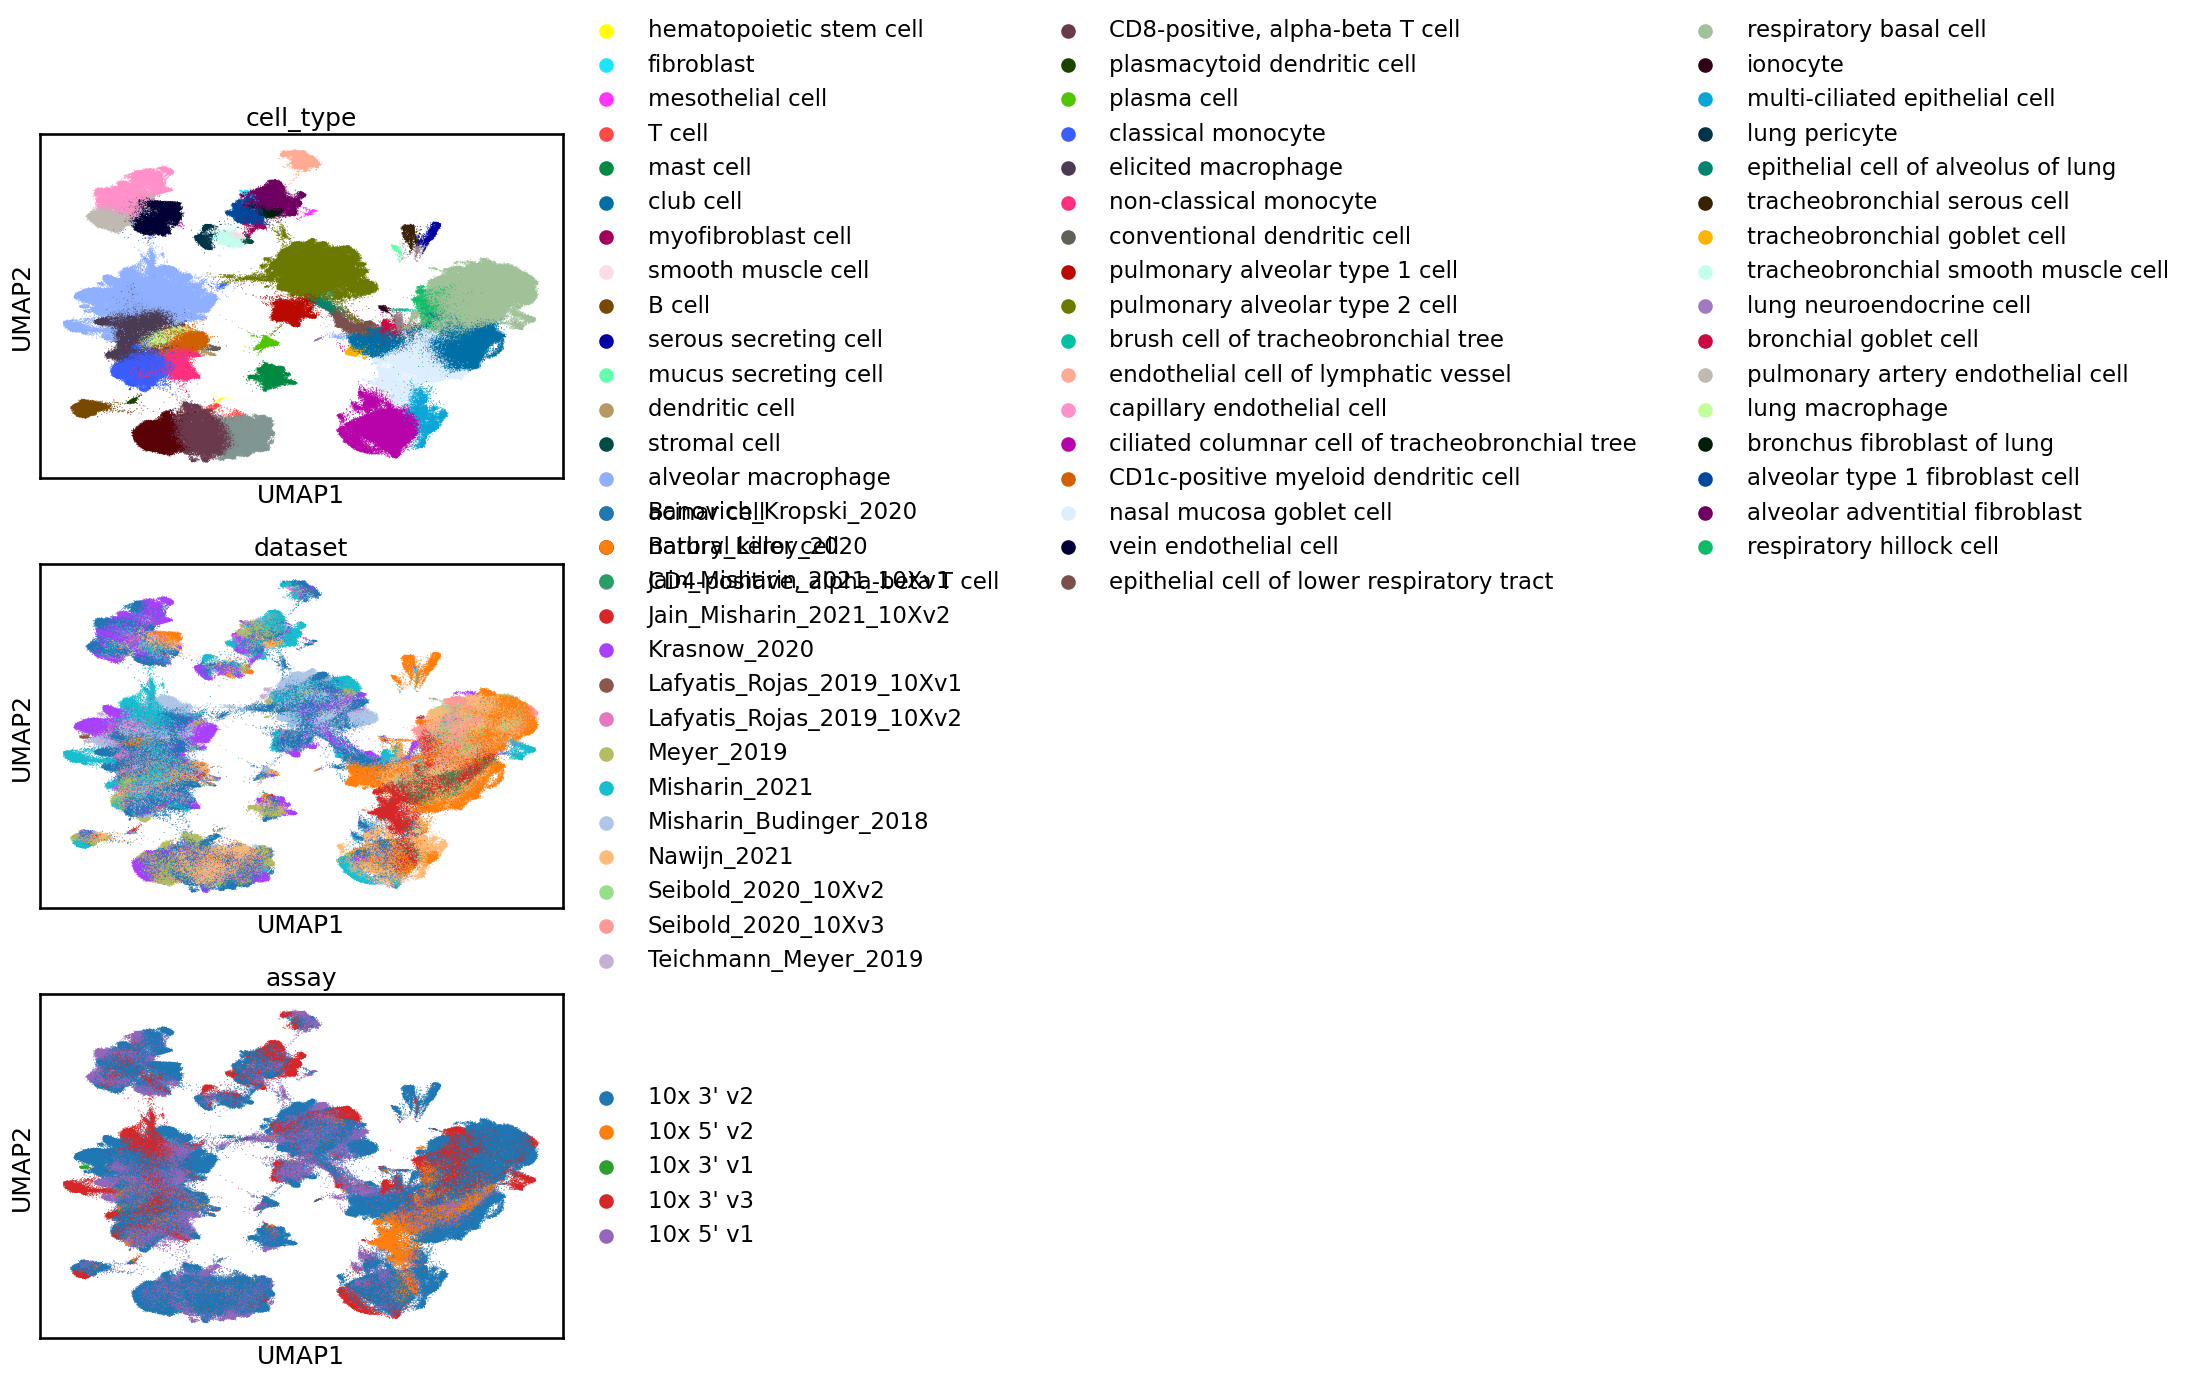

In [7]:
sc.pl.umap(
    adata,
    ncols=1,
    color=["cell_type", "dataset", "assay"],
    size=2,
)

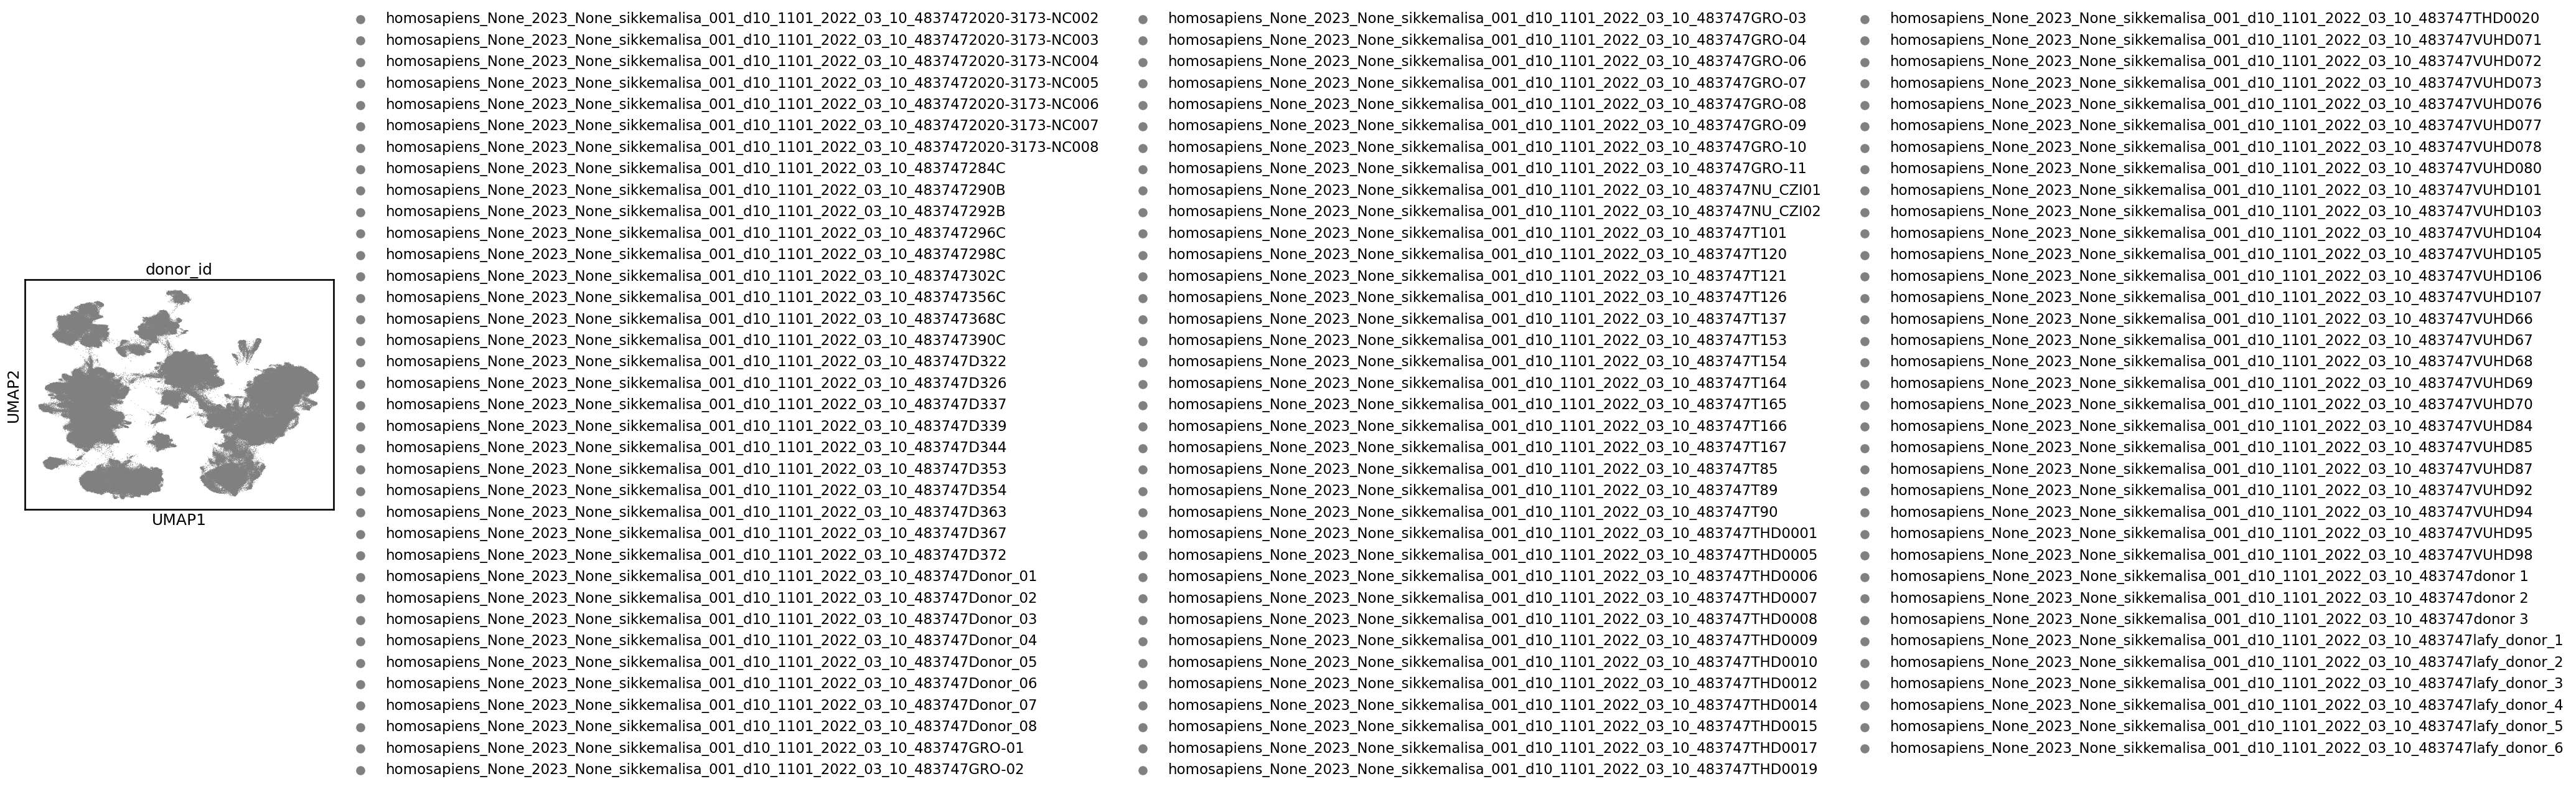

In [8]:
# too many donors to plot
sc.pl.umap(
    adata,
    ncols=1,
    color=["donor_id"],
    size=2,
)

In [9]:
# Save embedding
embedding = ad.AnnData(
    X=adata.obsm['X_scanvi_emb'],
    obs=adata.obs,
    uns={
        'method_id': model,
    }
)
embedding.write_h5ad("./../../embeddings/{}.embedding.h5ad".format(model), compression="gzip")

In [10]:
model = 'noIntegration_hlca'

In [ ]:
sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    ncols=1,
    color=["cell_type", "dataset", "assay"],
    size=2,
)

/fast/AG_Ohler/prauten/conda_envs/scib_metrics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# Save embedding
embedding = ad.AnnData(
    X=adata.obsm['X_pca'],
    obs=adata.obs,
    uns={
        'method_id': model,
    }
)
embedding.write_h5ad("./../../embeddings/{}.embedding.h5ad".format(model), compression="gzip")

In [ ]:
model = 'naiveIntegration_dataset_hlca'

In [ ]:
# Mild batch correction by batch-aware selection of highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="dataset")

sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    ncols=1,
    color=["cell_type", "dataset", "assay"],
    size=2,
)

In [ ]:
# Save embedding
embedding = ad.AnnData(
    X=adata.obsm['X_pca'],
    obs=adata.obs,
    uns={
        'method_id': model,
    }
)
embedding.write_h5ad("./../../embeddings/{}.embedding.h5ad".format(model), compression="gzip")

In [ ]:
model = 'naiveIntegration_donor_id_hlca'

In [ ]:
# Mild batch correction by batch-aware selection of highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="donor_id")

sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    ncols=1,
    color=["cell_type", "dataset", "assay"],
    size=2,
)

In [ ]:
# Save embedding
embedding = ad.AnnData(
    X=adata.obsm['X_pca'],
    obs=adata.obs,
    uns={
        'method_id': model,
    }
)
embedding.write_h5ad("./../../embeddings/{}.embedding.h5ad".format(model), compression="gzip")

In [ ]:
model = 'naiveIntegration_assay_hlca'

In [ ]:
# Mild batch correction by batch-aware selection of highly variable genes
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key="assay")

sc.tl.pca(adata)
sc.pp.neighbors(adata)
sc.tl.umap(adata)

sc.pl.umap(
    adata,
    ncols=1,
    color=["cell_type", "dataset", "assay"],
    size=2,
)

In [ ]:
# Save embedding
embedding = ad.AnnData(
    X=adata.obsm['X_pca'],
    obs=adata.obs,
    uns={
        'method_id': model,
    }
)
embedding.write_h5ad("./../../embeddings/{}.embedding.h5ad".format(model), compression="gzip")